# Robot control over Wi-Fi

> A custom channel model: a robot controlled from an access point, over a ray-traced Wi-Fi link with bursts of interference.

In [ ]:
import math

import matplotlib.pyplot as plt
import numpy as np

from comm_core import *

A robot drives along a path in a house and is controlled from an access point (AP). At regular intervals:

1. **Request:** the robot sends a camera image (224 × 224 RGB, about 100 Wi-Fi packets) to the AP.
2. **Policy:** the AP runs the policy (inference takes some time).
3. **Response:** it sends back the next actions, which the robot executes. When it runs out of actions, it stops
   and waits (a *stall*).

A request fails if one of its packets is still lost after the MAC's retries, and the robot then sends a new
image. Bursts of interference (or someone blocking the line of sight) make the link much worse for a while.

The question: does sending a long plan per request (`KT`, 40 actions) avoid the stalls that short action chunks
(`VLA`, 10 actions) suffer when the link is bad?

None of this is specific to comm-core: it is a model someone wrote for this question. Here is how its parts map
onto comm-core's:

| part of the model | comm-core |
|---|---|
| AP ↔ robot, 10 dBm uplink, 20 dBm downlink | `GraphTopology`, one `Link` per direction |
| Sionna RT paths every 5 cm along the route, moved in between | `RayTracedPathsFading` (`trace_paths` with a real scene) |
| bursts lowering the SINR for a while, the same for both methods | `GilbertElliottFading`, seeded |
| 802.11ac MCS 7: EESM over 52 subcarriers, a calibrated packet-error curve | `SystemLevelChannel` with `EESMErrorModel` |
| 1500-byte packets, up to 7 retries, 200 µs per attempt, 65 Mb/s | `FragmentingChannel` |
| request at a control step, reply after inference, arrival after the airtime | `Network(delayed_delivery=True)`, `send(..., at=...)` |
| the robot, its actions and stalls | the application: a loop around the network |

## The radio

An 802.11ac-like link: 20 MHz, 52 data subcarriers, a fixed MCS 7 (65 Mb/s).

In [ ]:
FREQUENCY = 5.18e9                                     # Wi-Fi channel 36
SUBCARRIERS = (np.arange(52) - 25.5) * 312.5e3         # 52 data subcarriers of a 20 MHz channel
NOISE_W = 10 ** ((-174 + 10 * np.log10(20e6) + 7.0 - 30) / 10)   # thermal noise over 20 MHz, 7 dB noise figure
AP = np.array([0.0, 0.0, 2.4])
ROBOT_HEIGHT = 0.4

## Propagation: paths at anchors

With a real scene, trace the paths from the AP to anchors every 5 cm over the area the robot drives through, on
a machine with Sionna RT, and save them:

```python
from sionna.rt import load_scene
scene = load_scene('small_house_imported.xml')
scene.frequency = FREQUENCY
area = grid_points((-7.0, -3.5), (-3.0, 0.0), 0.05, height=ROBOT_HEIGHT)
RayTracedPathsFading(**trace_paths(scene, [AP], area, max_depth=6)).save('house_paths.npz')
```

Then `RayTracedPathsFading.from_npz('house_paths.npz', subcarriers=SUBCARRIERS)`. To run here without the scene,
the paths come from a simple room: a line-of-sight path and a reflection off each of two walls (image method).

In [ ]:
C = 299_792_458.0
WALLS = [(1, 3.0, -0.6), (0, -8.0, -0.5)]              # (axis, coordinate, reflection coefficient)

def room_paths(tx, rx):
    "The paths from tx to rx: line of sight and one reflection off each wall."
    sources = [(tx, 1.0, np.eye(3))]
    for axis, c, gamma in WALLS:
        mirror = np.eye(3); mirror[axis, axis] = -1
        sources.append((mirror @ tx + 2 * c * np.eye(3)[axis], gamma, mirror))
    a, tau, u_tx, u_rx = [], [], [], []
    for source, gamma, mirror in sources:
        v = rx - source; length = np.linalg.norm(v)
        a.append(gamma * C / FREQUENCY / (4 * np.pi * length) * np.exp(-2j * np.pi * FREQUENCY * length / C))
        tau.append(length / C); u_rx.append(-v / length); u_tx.append(mirror @ (v / length))
    return a, tau, u_tx, u_rx

area = grid_points((-7.0, -3.5), (-3.0, 0.0), 0.05, height=ROBOT_HEIGHT)    # anchors every 5 cm
traced = [room_paths(AP, p) for p in area]
paths = RayTracedPathsFading(AP[None], area, *(np.array([t[k] for t in traced])[None] for k in range(4)),
                             frequency=FREQUENCY, subcarriers=SUBCARRIERS)
paths.set_positions({'ap': AP, 'robot': (-4.8, -2.8, ROBOT_HEIGHT)})
print(f"{len(area)} anchors; path gain at the start of the route: {10 * np.log10(paths.path_gain('ap', 'robot')):.1f} dB")

5751 anchors; path gain at the start of the route: -58.8 dB


## The link: bursts, EESM, packets and retries

The pieces stack:

1. `GilbertElliottFading` weakens the paths by `penalty_db` during bursts (3 s apart on average, 0.6 s long).
2. `SystemLevelChannel` gives each packet the SINR at each subcarrier.
3. `EESMErrorModel` turns those SINRs into the packet's error rate (MCS 7: β = 28, 10% of 1000-byte packets lost at
   21 dB, approximate values).
4. `FragmentingChannel` splits a message into 1500-byte packets, retries each up to 7 times, and counts the
   airtime. Each attempt is at its own time, so it sees the burst state at that moment.

In [ ]:
def wifi_channel(penalty_db):
    radio = SystemLevelChannel(
        fading=GilbertElliottFading(paths, mean_good_s=3.0, mean_bad_s=0.6, penalty_db=penalty_db),
        noise_power=NOISE_W,
        per_model=EESMErrorModel(beta=28.0, threshold_db=21.0, slope=1.5),
    )
    return FragmentingChannel(radio, mtu_bits=8 * 1500, retry_limit=7, overhead_s=200e-6, rate_bps=65e6)

def network(penalty_db, seed):
    topology = GraphTopology([Link('robot', 'ap', tx_power_w=10 ** ((10 - 30) / 10), bandwidth_hz=20e6),   # 10 dBm up
                              Link('ap', 'robot', tx_power_w=10 ** ((20 - 30) / 10), bandwidth_hz=20e6)])  # 20 dBm down
    channel = wifi_channel(penalty_db)
    net = Network([Node('robot'), Node('ap')], topology, IdealProtocol(), AnalyticalBackend(channel), delayed_delivery=True)
    net.reset(seed)                                     # the same seed: the same bursts, whatever the method
    return net, channel

## The robot

The application: every 0.1 s, the robot moves if it has actions left, and asks for new ones 3 actions before it
needs them. The network carries the messages:

* **The request** is sent at once (`step(dt=0)`).
* **The reply:** when the AP has the image, it replies after its inference time (`send(..., at=...)`).
* **Arrival:** the actions arrive when their packets are through (`delayed_delivery`).
* **Failure:** a failed request is noticed when its last retry ends.

In [ ]:
METHODS = {
    'VLA': dict(actions=10, inference_s=0.05, reply_bytes=10 * 7 * 4),   # 10 actions of 7 floats
    'KT': dict(actions=40, inference_s=0.08, reply_bytes=600),            # an encoded plan of 40 actions
}
ROUTES = {
    'VLA': [(-4.8, -2.8), (-3.6, -1.6), (-3.8, -1.2), (-6.4, -0.6)],
    'KT': [(-4.8, -2.8), (-3.5, -1.75), (-3.6, -1.1), (-6.4, -0.5)],
}
DT, SPEED, REPLAN_EVERY, LEAD, IMAGE_BYTES, T_MAX = 0.1, 0.25, 10, 3, 224 * 224 * 3, 300.0

def run(method, route, penalty_db, seed, log=False):
    cfg = METHODS[method]
    route = np.asarray(route, float)
    along = np.r_[0, np.cumsum(np.linalg.norm(np.diff(route, axis=0), axis=1))]
    where = lambda s: (np.interp(s, along, route[:, 0]), np.interp(s, along, route[:, 1]), ROBOT_HEIGHT)
    net, channel = network(penalty_db, seed)
    t = s = stall = 0.0
    actions = since = requests = fails = 0
    started = waiting = False
    failed_at = None
    trace, oks, failures = [], [], []

    def handle(results):
        nonlocal failed_at
        for r in results:
            sent = r.transmission
            if r.success and sent.message.type == 'image':          # the AP has the image: it answers after inference
                reply = Message('ap', 'robot', None, type='actions', size_bits=8 * cfg['reply_bytes'])
                net.send(reply, at=sent.start_time + r.latency + cfg['inference_s'])
            elif not r.success:                                      # lost: known when the last retry is over
                failed_at = sent.start_time + r.latency

    while s < along[-1] - 1e-9 and t < T_MAX:
        channel.set_positions({'ap': AP, 'robot': where(s)})
        handle(net.step_to(t))
        if net.receive('robot'):                                     # new actions
            actions, since, started, waiting = cfg['actions'], 0, True, False
            oks.append(t)
        if failed_at is not None and failed_at <= t:
            fails, failed_at, waiting = fails + 1, None, False
            failures.append(t)
        if not waiting and (not started or since >= REPLAN_EVERY - LEAD):
            net.send(Message('robot', 'ap', None, type='image', size_bits=8 * IMAGE_BYTES))
            handle(net.step(dt=0.0))                                 # it leaves now
            requests, waiting = requests + 1, True
        if actions > 0:
            s, actions, since = min(along[-1], s + SPEED * DT), actions - 1, since + 1
        elif started:
            stall += DT
        trace.append((t, actions, s))
        t += DT
    out = dict(stall=stall, requests=requests, fails=fails, time=t)
    if log:
        out.update(trace=np.array(trace), oks=oks, failures=failures, bursts=channel.channel.fading.episodes(t))
    return out

## One run

One run at a 30 dB burst penalty, for both methods. The red bands are bursts (the same for both).

* **Top:** how many actions the robot has left.
* **Middle:** how far along the route it is. Flat stretches are stalls.
* **Bottom:** the replies that arrived (|) and the requests that failed (×).

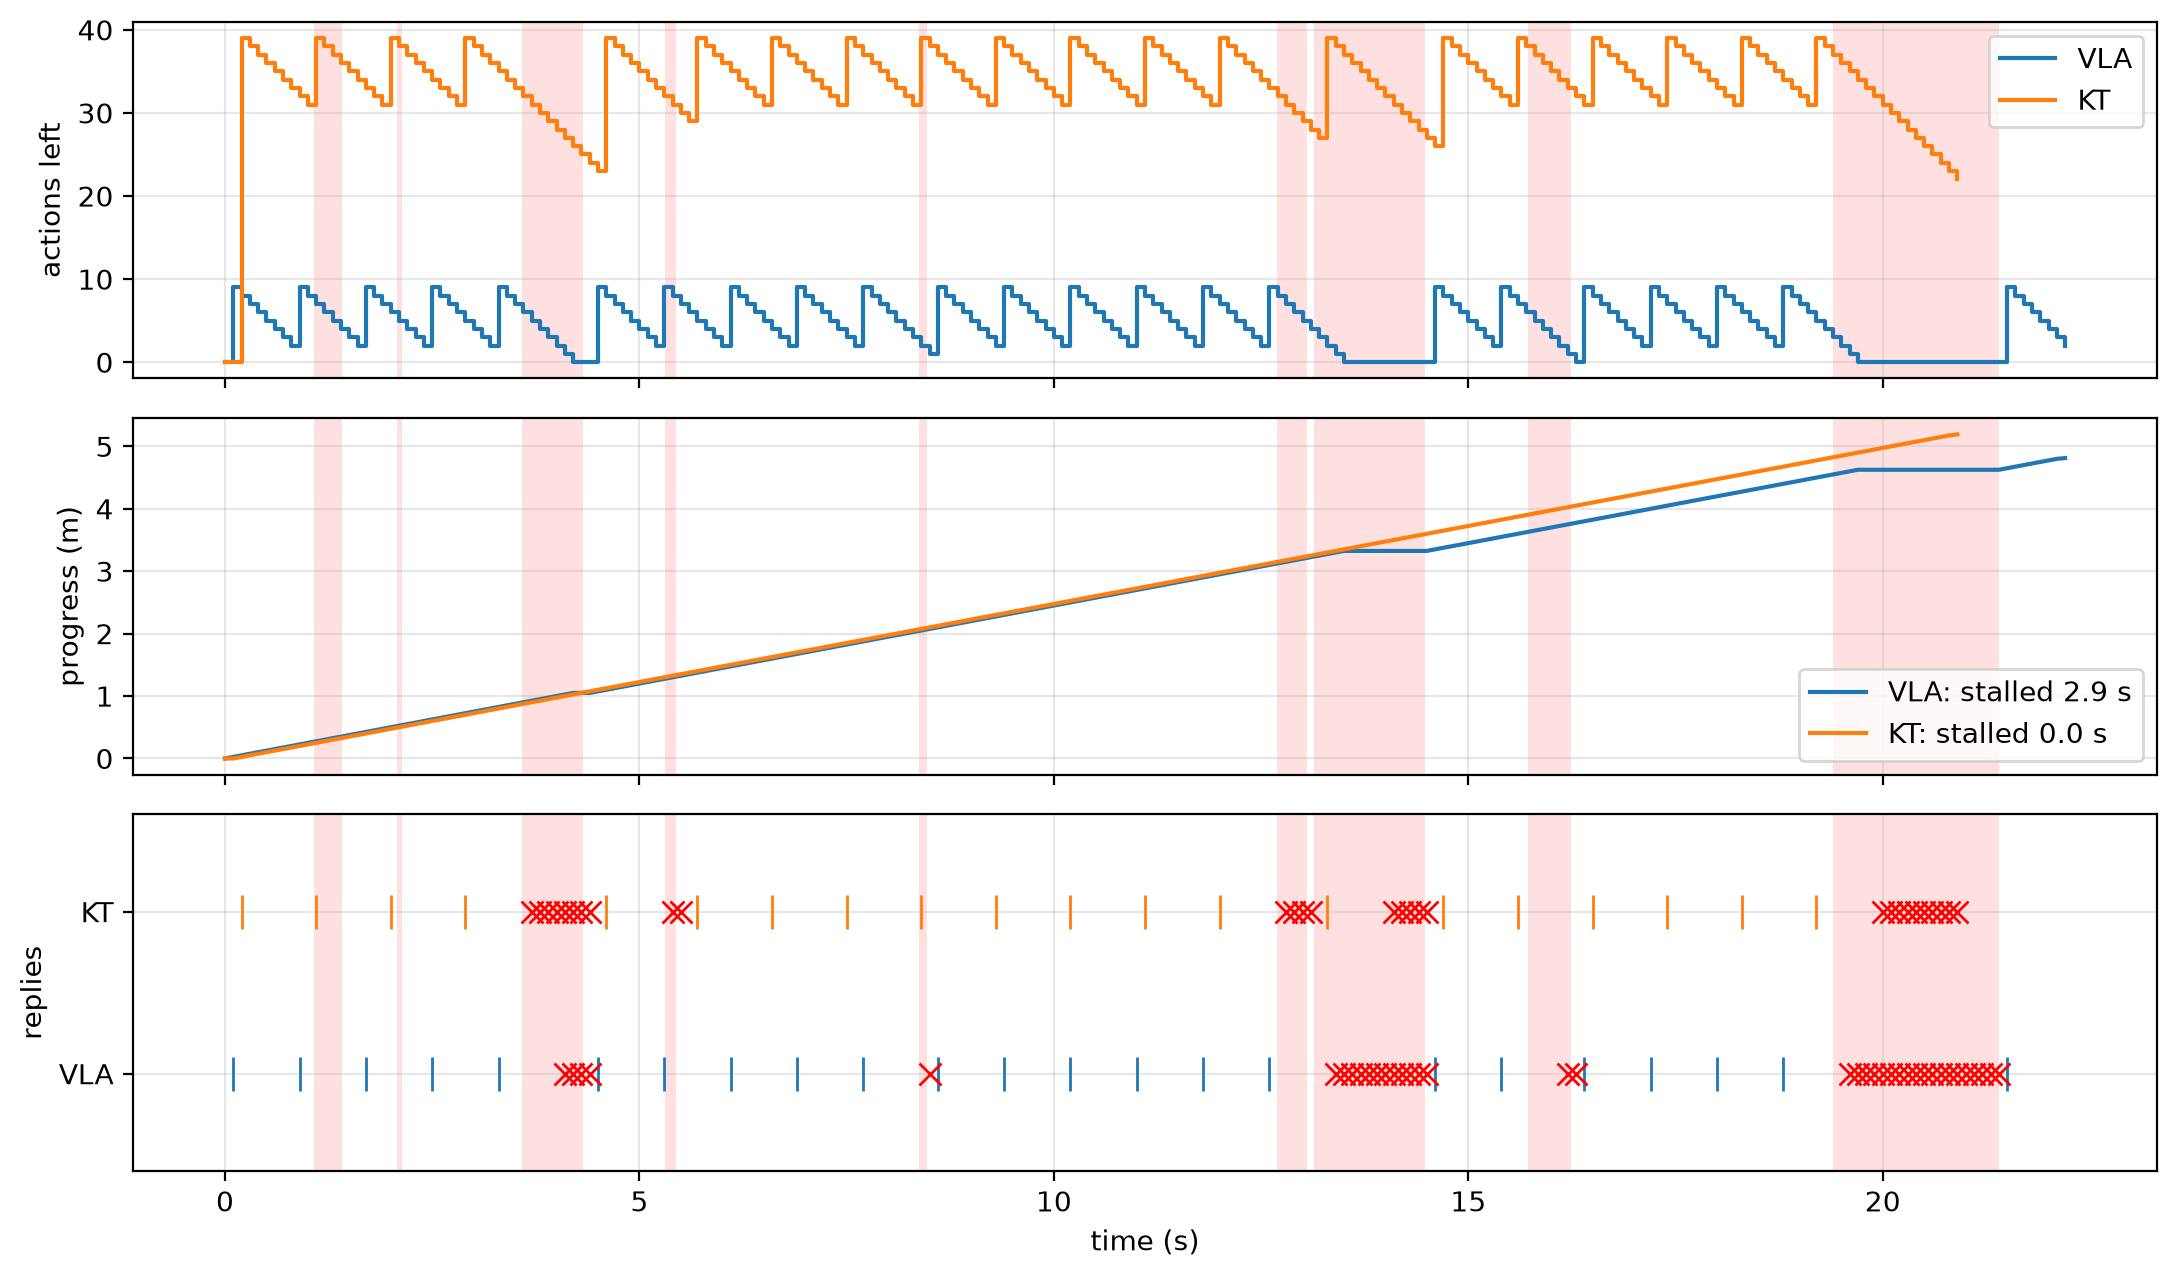

In [ ]:
seed = next(s for s in range(30) if run('VLA', ROUTES['VLA'], 30, s)['stall'] > 0)          # a run where VLA stalls
runs = {m: run(m, ROUTES[m], 30, seed, log=True) for m in METHODS}
fig, axes = plt.subplots(3, 1, figsize=(11, 6.5), sharex=True)
end = max(r['time'] for r in runs.values())
for ax in axes:
    for a, b in runs['VLA']['bursts']:
        ax.axvspan(a, min(b, end), color='red', alpha=0.12, lw=0)
for k, (m, r) in enumerate(runs.items()):
    tr = r['trace']
    axes[0].step(tr[:, 0], tr[:, 1], where='post', label=m)
    axes[1].plot(tr[:, 0], tr[:, 2], label=f"{m}: stalled {r['stall']:.1f} s")
    axes[2].plot(r['oks'], [k] * len(r['oks']), '|', ms=12, color=f'C{k}')
    axes[2].plot(r['failures'], [k] * len(r['failures']), 'x', ms=8, color='red')
axes[0].set(ylabel='actions left'); axes[1].set(ylabel='progress (m)')
axes[2].set(yticks=range(len(runs)), yticklabels=list(runs), ylim=(-0.6, len(runs) - 0.4), ylabel='replies', xlabel='time (s)')
axes[0].legend(loc='upper right'); axes[1].legend(loc='lower right')
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
assert runs['VLA']['stall'] > runs['KT']['stall']

## Results

30 runs per point. Within a run, both methods see the same bursts. The sweep takes a few minutes, so it is flagged `slow`: `nbdev_test --flags slow` runs it.

In [ ]:
one = run('VLA', ROUTES['VLA'], 30, 0)                  # one run, with bad bursts
assert one['requests'] > 0 and one['time'] < T_MAX and one['stall'] >= 0


In [ ]:
#| slow
print('burst SINR drop | ' + ' | '.join(f'{m}: mean stall, runs with a stall, failed requests' for m in METHODS))
for penalty_db in (0, 10, 20, 30):
    row = []
    for method in METHODS:
        runs = [run(method, ROUTES[method], penalty_db, seed) for seed in range(30)]
        stall = np.array([r['stall'] for r in runs])
        failed = sum(r['fails'] for r in runs) / sum(r['requests'] for r in runs)
        row.append(f'{method}: {stall.mean():4.2f} s, {np.mean(stall > 0):4.2f}, {100 * failed:4.1f} %')
    print(f'{penalty_db:9d} dB   | ' + ' | '.join(row))

burst SINR drop | VLA: mean stall, runs with a stall, failed requests | KT: mean stall, runs with a stall, failed requests
        0 dB   | VLA: 0.00 s, 0.00,  0.0 % | KT: 0.00 s, 0.00,  0.0 %
       10 dB   | VLA: 0.00 s, 0.00,  0.0 % | KT: 0.00 s, 0.00,  0.0 %
       20 dB   | VLA: 0.00 s, 0.00,  1.6 % | KT: 0.00 s, 0.00,  3.5 %
       30 dB   | VLA: 1.25 s, 0.87, 42.8 % | KT: 0.00 s, 0.00, 41.1 %


With bad enough bursts, a request that falls in one fails, and the robot runs out of actions before a new one
gets through. With 10 actions per response (1 s), that happens often. With a 40-action plan (4 s), the robot
usually still has actions left when the burst ends.

**To use your own model,** each piece can be swapped on its own:

* **Scene:** the paths of a real scene, traced with `trace_paths`.
* **Error model:** 5G NR's (`SionnaErrorModel`), or your own subclass of `ErrorModel`.
* **Time-varying effects:** another `Fading` that reads the transmission's time.
* **Medium access:** another protocol, e.g. `TDMAProtocol` with several robots.

The application, the robot loop, stays the same.